<a href="https://colab.research.google.com/github/Mary584-dev/my-one-of-codes/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model    import LogisticRegression
from sklearn.linear_model    import LinearRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
#import warnings
#warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('/content/ACSI Data 2015.xlsx')
df

,INDUSTRY,YEAR,SATIS,CONFIRM,IDEAL,OVERALLX,CUSTOMX,WRONGX,OVERALLQ,CUSTOMQ,...,EDUCAT,HISPANIC,RACE_1,RACE_2,RACE_3,RACE_4,RACE_5,INCOME,GENDER,ZIPCODE
0,3003,2015,9,8,8,10.0,9.0,9.0,9.0,9.0,...,4.0,0.0,1.0,NaN,NaN,NaN,NaN,7.0,1.0,25177.0
1,3003,2015,8,6,7,8.0,8.0,8.0,8.0,8.0,...,4.0,0.0,1.0,NaN,NaN,NaN,NaN,1.0,2.0,2474.0
2,3003,2015,8,8,9,9.0,8.0,8.0,9.0,9.0,...,4.0,0.0,1.0,NaN,NaN,NaN,NaN,99.0,2.0,48374.0
3,3003,2015,8,8,8,9.0,8.0,8.0,8.0,8.0,...,5.0,0.0,4.0,NaN,NaN,NaN,NaN,5.0,2.0,92614.0
4,3003,2015,9,8,8,8.0,9.0,10.0,8.0,8.0,...,3.0,0.0,2.0,NaN,NaN,NaN,NaN,4.0,1.0,2125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8234,5001,2015,7,3,4,5.0,3.0,7.0,6.0,8.0,...,1.0,0.0,1.0,NaN,NaN,NaN,NaN,2.0,2.0,77566.0
8235,5001,2015,3,3,3,6.0,5.0,8.0,3.0,3.0,...,5.0,0.0,1.0,NaN,NaN,NaN,NaN,4.0,2.0,29115.0
8236,5001,2015,3,3,3,6.0,6.0,6.0,3.0,3.0,...,3.0,0.0,1.0,NaN,NaN,NaN,NaN,1.0,2.0,35175.0
8237,5001,2015,5,5,5,5.0,5.0,8.0,5.0,6.0,...,3.0,0.0,1.0,NaN,NaN,NaN,NaN,5.0,2.0,8753.0


In [ ]:
df.isna().sum()

,0
INDUSTRY,0
YEAR,0
SATIS,0
CONFIRM,0
IDEAL,0
OVERALLX,168
CUSTOMX,168
WRONGX,168
OVERALLQ,168
CUSTOMQ,168


In [ ]:
df.duplicated().sum()

np.int64(20)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8219 entries, 0 to 8238
Data columns (total 29 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   INDUSTRY  8219 non-null   int64  
 1   YEAR      8219 non-null   int64  
 2   SATIS     8219 non-null   int64  
 3   CONFIRM   8219 non-null   int64  
 4   IDEAL     8219 non-null   int64  
 5   OVERALLX  8051 non-null   float64
 6   CUSTOMX   8051 non-null   float64
 7   WRONGX    8051 non-null   float64
 8   OVERALLQ  8051 non-null   float64
 9   CUSTOMQ   8051 non-null   float64
 10  WRONGQ    8051 non-null   float64
 11  PQ        8051 non-null   float64
 12  QP        8051 non-null   float64
 13  COMP      8051 non-null   float64
 14  HANDLE    1375 non-null   float64
 15  REPUR     8051 non-null   float64
 16  HIGHPTOL  6523 non-null   float64
 17  LOWPTOL   1284 non-null   float64
 18  AGE       8219 non-null   int64  
 19  EDUCAT    8149 non-null   float64
 20  HISPANIC  8149 non-null   float64
 

In [ ]:
df = df.drop(columns=['RACE_2','RACE_3','RACE_4','RACE_5','HANDLE','LOWPTOL','ZIPCODE','INDUSTRY','YEAR'], axis=1)

In [ ]:
df

,SATIS,CONFIRM,IDEAL,OVERALLX,CUSTOMX,WRONGX,OVERALLQ,CUSTOMQ,WRONGQ,PQ,QP,COMP,REPUR,HIGHPTOL,AGE,EDUCAT,HISPANIC,RACE_1,INCOME,GENDER
0,9,8,8,10.0,9.0,9.0,9.0,9.0,9.0,9.0,9.0,0.0,9.0,98.0,67,4.0,0.0,1.0,7.0,1.0
1,8,6,7,8.0,8.0,8.0,8.0,8.0,9.0,8.0,8.0,0.0,8.0,5.0,32,4.0,0.0,1.0,1.0,2.0
2,8,8,9,9.0,8.0,8.0,9.0,9.0,9.0,4.0,4.0,0.0,9.0,15.0,49,4.0,0.0,1.0,99.0,2.0
3,8,8,8,9.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,0.0,7.0,26.0,32,5.0,0.0,4.0,5.0,2.0
4,9,8,8,8.0,9.0,10.0,8.0,8.0,8.0,9.0,9.0,0.0,8.0,10.0,24,3.0,0.0,2.0,4.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8234,7,3,4,5.0,3.0,7.0,6.0,8.0,8.0,3.0,4.0,0.0,4.0,NaN,28,1.0,0.0,1.0,2.0,2.0
8235,3,3,3,6.0,5.0,8.0,3.0,3.0,1.0,2.0,2.0,1.0,2.0,NaN,56,5.0,0.0,1.0,4.0,2.0
8236,3,3,3,6.0,6.0,6.0,3.0,3.0,3.0,4.0,4.0,0.0,2.0,NaN,44,3.0,0.0,1.0,1.0,2.0
8237,5,5,5,5.0,5.0,8.0,5.0,6.0,9.0,5.0,5.0,0.0,5.0,NaN,56,3.0,0.0,1.0,5.0,2.0


In [ ]:
pd.DataFrame({
    'min': df.min(),
    'max': df.max(),
    'mean': df.mean()
})

,min,max,mean
SATIS,1.0,99.0,7.884658
CONFIRM,1.0,99.0,7.516973
IDEAL,1.0,99.0,7.975544
OVERALLX,1.0,99.0,10.121476
CUSTOMX,1.0,99.0,9.246181
WRONGX,1.0,99.0,9.478823
OVERALLQ,1.0,99.0,8.535834
CUSTOMQ,1.0,99.0,8.493479
WRONGQ,1.0,99.0,8.702397
PQ,1.0,99.0,8.542790


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8219 entries, 0 to 8238
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SATIS     8219 non-null   int64  
 1   CONFIRM   8219 non-null   int64  
 2   IDEAL     8219 non-null   int64  
 3   OVERALLX  8051 non-null   float64
 4   CUSTOMX   8051 non-null   float64
 5   WRONGX    8051 non-null   float64
 6   OVERALLQ  8051 non-null   float64
 7   CUSTOMQ   8051 non-null   float64
 8   WRONGQ    8051 non-null   float64
 9   PQ        8051 non-null   float64
 10  QP        8051 non-null   float64
 11  COMP      8051 non-null   float64
 12  REPUR     8051 non-null   float64
 13  HIGHPTOL  6523 non-null   float64
 14  AGE       8219 non-null   int64  
 15  EDUCAT    8149 non-null   float64
 16  HISPANIC  8149 non-null   float64
 17  RACE_1    8149 non-null   float64
 18  INCOME    8149 non-null   float64
 19  GENDER    8149 non-null   float64
dtypes: float64(16), int64(4)
memory usa

In [ ]:
df.fillna({
    'OVERALLX':df['OVERALLX'].mean(),
    'CUSTOMX'	:df['CUSTOMX'].mean(),
    'WRONGX'	:df['WRONGX'].mean(),
    'OVERALLQ'	:df['OVERALLQ'].mean(),
    'CUSTOMQ'	:df['CUSTOMQ'].mean(),
    'WRONGQ'	:df['WRONGQ'].mean(),
    'PQ': df['PQ'].mean(),
    'QP'	:df['QP'].mean(),
    'COMP':df['COMP'].mean(),
    'REPUR'	:df['REPUR'].mean(),
'HIGHPTOL'  :df['HIGHPTOL'].mean(),
    'EDUCAT'	:df['EDUCAT'].mean(),
'HISPANIC'	:df['HISPANIC'].mean(),
'RACE_1':df['RACE_1'].mean(),
'INCOME'	:df['INCOME'].mean(),
'GENDER'	:df['GENDER'].mean()
},inplace = True)
df.isna().sum()

,0
SATIS,0
CONFIRM,0
IDEAL,0
OVERALLX,0
CUSTOMX,0
WRONGX,0
OVERALLQ,0
CUSTOMQ,0
WRONGQ,0
PQ,0


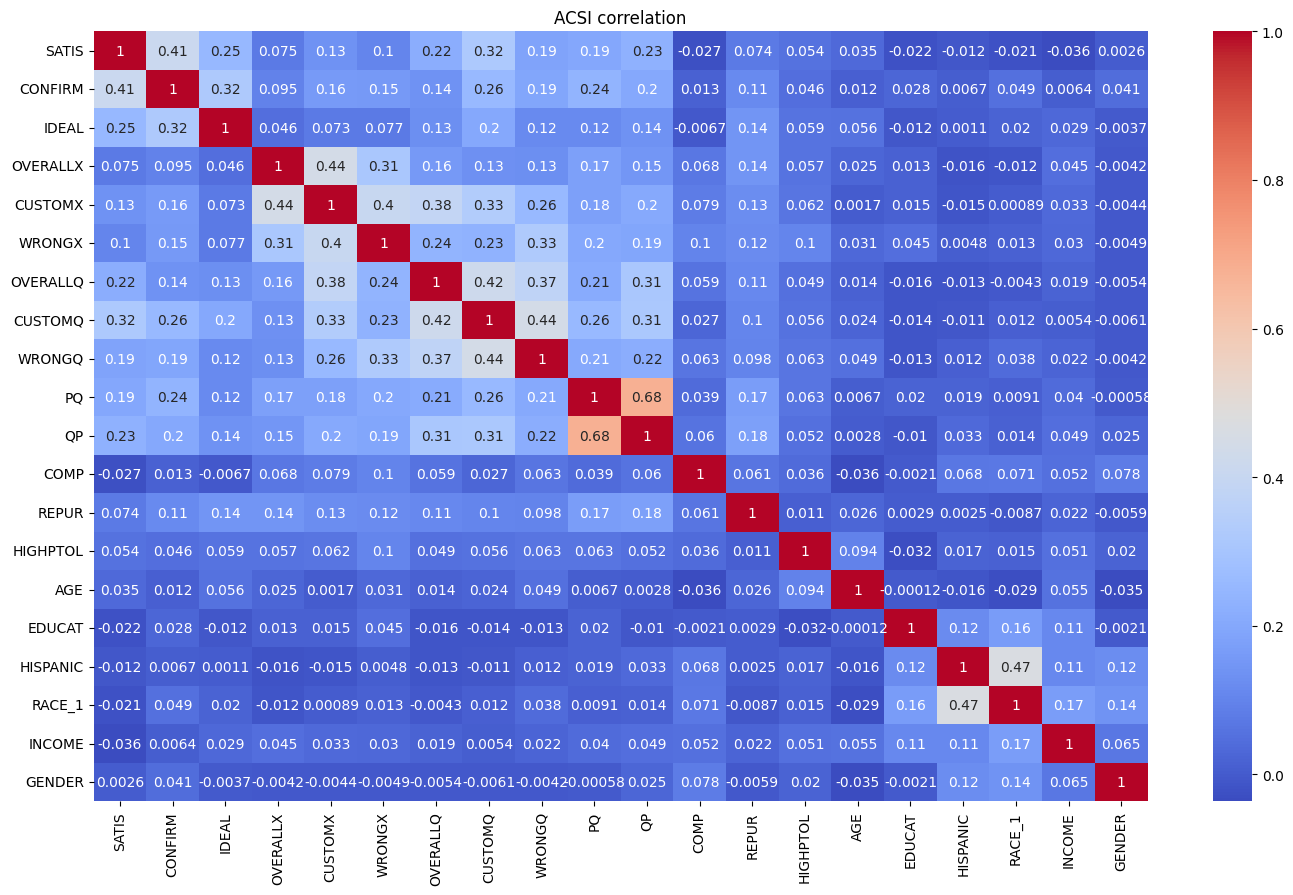

In [ ]:
correlation = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(17,10))
sns.heatmap(correlation.corr(),annot=True,cmap = 'coolwarm')
plt.title('ACSI correlation')
plt.show()

<Axes: xlabel='SATIS', ylabel='count'>

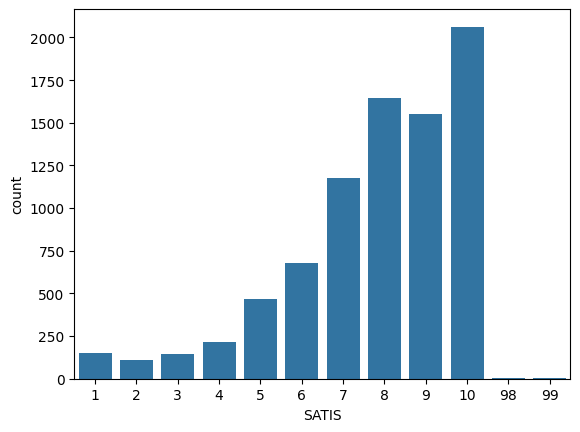

In [ ]:
sns.barplot(df['SATIS'].value_counts())

In [ ]:
x = df.drop('SATIS', axis= 1)
y = df['SATIS']
x_Train,x_test,y_Train,y_test = train_test_split(x,y , test_size=0.2,random_state=42,stratify = y)


In [ ]:
params ={
 'C':[0.001,0.01,0.1,1,10],
 'solver':['saga'],
 'max_iter':[100,200,300,500,1000],
}
LoR = LogisticRegression(random_state=42)

gridsearch=GridSearchCV(estimator=LoR,
                         param_grid= params,
                         cv=5,
                         verbose = 1,
                         n_jobs=-1)
gridsearch.fit(x_Train,y_Train)
bestLoR=gridsearch.best_estimator_
y_predict=bestLoR.predict(x_test)
print(classification_report(y_test,y_predict))
print('Best parameter: ',gridsearch.best_params_)
print('Best cv score: ' ,gridsearch.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


              precision    recall  f1-score   support

           1       0.62      0.87      0.72        30
           2       0.05      0.05      0.05        21
           3       0.00      0.00      0.00        29
           4       0.17      0.02      0.04        44
           5       0.18      0.12      0.14        94
           6       0.00      0.00      0.00       136
           7       0.19      0.16      0.17       236
           8       0.29      0.29      0.29       329
           9       0.12      0.01      0.02       311
          10       0.39      0.90      0.54       413
          98       0.00      0.00      0.00         1

    accuracy                           0.33      1644
   macro avg       0.18      0.22      0.18      1644
weighted avg       0.23      0.33      0.24      1644

Best parameter:  {'C': 0.1, 'max_iter': 1000, 'solver': 'saga'}
Best cv score:  0.3274524714828898


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
param ={
 'p':[1,2],
 'n_neighbors':[1,2,3,4,5,6,7,8,9,10],
 'weights':['uniform','distance'],
 'metric':['minkowski']
}
KN = KNeighborsClassifier()

gridsearch=GridSearchCV(estimator=KN,
                         param_grid= param,
                         cv=5,
                         verbose = 1,
                         n_jobs=-1)
gridsearch.fit(x_Train,y_Train)
bestKN=gridsearch.best_estimator_
y_predict=bestKN.predict(x_test)
print(classification_report(y_test,y_predict))
print('Best Parameters: ',gridsearch.best_params_)
print('Best cv Score: ' ,gridsearch.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 40 candidates, totalling 200 fits
              precision    recall  f1-score   support

           1       0.74      0.83      0.78        30
           2       0.00      0.00      0.00        21
           3       0.28      0.24      0.26        29
           4       0.33      0.18      0.24        44
           5       0.37      0.43      0.39        94
           6       0.35      0.26      0.30       136
           7       0.41      0.42      0.42       236
           8       0.46      0.52      0.49       329
           9       0.49      0.47      0.48       311
          10       0.79      0.84      0.82       413
          98       0.00      0.00      0.00         1

    accuracy                           0.53      1644
   macro avg       0.38      0.38      0.38      1644
weighted avg       0.52      0.53      0.53      1644

Best Parameters:  {'metric': 'minkowski', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best cv Score:  0.5376425855513307

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
params ={
    'min_samples_split':[2,3,4,5],
    'criterion':['gini','entropy'],
    'max_depth':[3,6],
    'min_samples_leaf':[1,2,3],

}
DT = DecisionTreeClassifier(random_state=42)

gridsearch=GridSearchCV(estimator=DT,
                         param_grid= params,
                         cv=5,
                         scoring='accuracy',
                         verbose = 1,
                         n_jobs=-1)
gridsearch.fit(x_Train,y_Train)
bestDT=gridsearch.best_estimator_
y_predict=bestDT.predict(x_test)
print(classification_report(y_test,y_predict))
print('Best parameters: ',gridsearch.best_params_)
print('Best cv score: ' ,gridsearch.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 48 candidates, totalling 240 fits
              precision    recall  f1-score   support

           1       0.83      0.80      0.81        30
           2       0.69      0.43      0.53        21
           3       0.55      0.38      0.45        29
           4       0.48      0.45      0.47        44
           5       0.43      0.44      0.43        94
           6       0.40      0.32      0.35       136
           7       0.50      0.46      0.48       236
           8       0.50      0.58      0.54       329
           9       0.52      0.57      0.54       311
          10       0.84      0.81      0.83       413
          98       0.00      0.00      0.00         1

    accuracy                           0.58      1644
   macro avg       0.52      0.48      0.49      1644
weighted avg       0.59      0.58      0.58      1644

Best parameters:  {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cv score:  0.5

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
 dparam ={
 'min_samples_split':[1,2,3],
'min_samples_leaf':[1,3,5],
 'max_depth':[4,7],
 'n_estimators':[50,100,200,400]

}
RF = RandomForestClassifier(random_state=42)

gridsearch=GridSearchCV(estimator=RF,
                         param_grid= param,
                         cv=5,
                         scoring='accuracy',
                         verbose = 1,
                         n_jobs=-1)
gridsearch.fit(x_Train,y_Train)
bestRF=gridsearch.best_estimator_
y_predict=bestRF.predict(x_test)

print(classification_report(y_test,y_predict))
print('Best Parameters: ',gridsearch.best_params_)
print('Best cv score: ' ,gridsearch.best_score_)

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Fitting 5 folds for each of 72 candidates, totalling 360 fits


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
120 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_

              precision    recall  f1-score   support

           1       0.74      0.87      0.80        30
           2       0.80      0.19      0.31        21
           3       0.42      0.38      0.40        29
           4       0.40      0.05      0.08        44
           5       0.42      0.52      0.46        94
           6       0.60      0.38      0.46       136
           7       0.50      0.53      0.52       236
           8       0.55      0.67      0.60       329
           9       0.61      0.58      0.60       311
          10       0.84      0.87      0.85       413
          98       0.00      0.00      0.00         1

    accuracy                           0.62      1644
   macro avg       0.54      0.46      0.46      1644
weighted avg       0.62      0.62      0.61      1644

Best Parameters:  {'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best cv score:  0.6101901140684409


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
significance = bestRF.feature_importances_
feat = x.columns
fi = (
    pd.DataFrame({'variable': feat, 'value':significance})
    .reset_index(drop=True)
    .sort_values('value',ascending=False)
)
display(fi.head(20))

,variable,value
6,CUSTOMQ,0.177952
5,OVERALLQ,0.159349
9,QP,0.153198
0,CONFIRM,0.130989
1,IDEAL,0.104873
8,PQ,0.082381
11,REPUR,0.078280
3,CUSTOMX,0.027390
7,WRONGQ,0.025989
2,OVERALLX,0.014458
